# Diabetes Risk Project: Model Engineering

This notebook picks up where `01_eda_cleaning.ipynb` left off. Based on the correlation analysis there, the features used are `HighBP`, `HighChol`, `BMI`, `HeartDiseaseorAttack`, `GenHlth`, `PhysHlth`, `DiffWalk`, and `Age`.

## Feature Modeling and Evaluation

In [ ]:
# Install necessary packages for model engineering
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              ConfusionMatrixDisplay, precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight
import joblib

In [ ]:
# Read csv file into dataframe (same raw file used in 01_eda_cleaning.ipynb —
# no rows were dropped or altered during cleaning, so no intermediate file is needed)
diabetes_df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

In [ ]:
# Split the diabetes data into train and test sets
X = diabetes_df[['HighBP', 'HighChol', 'BMI', 'HeartDiseaseorAttack', 'GenHlth', 'PhysHlth', 'DiffWalk', 'Age']]
y = diabetes_df['Diabetes_012']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 7, stratify = y)

The features used in the model are all float types. No encoding is needed since all features are already numerically encoded. BMI and Age are continuous features, so the remaining binary/ordinal features technically don't require scaling, but `StandardScaler` is applied uniformly for consistency.

In [ ]:
# Address class imbalance via class weighting
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.3956896090700037), 1: np.float64(18.257865515114126), 2: np.float64(2.3923692506668823)}


In [ ]:
# Scale only, BMI and Age are affected but binary features are unaffected
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 1. Logistic Regression - handles linearity, interpretable baseline
lr = LogisticRegression(class_weight=class_weight_dict, max_iter=1000, random_state=7)
lr.fit(X_train_scaled, y_train)

# 2. Random Forest — handles non-linearity, gives feature importance
rf = RandomForestClassifier(class_weight=class_weight_dict, n_estimators=100, random_state=7)
rf.fit(X_train_scaled, y_train)

# 3. XGBoost — strongest performer
xgb = XGBClassifier(scale_pos_weight=class_weights[1], use_label_encoder=False, eval_metric='mlogloss', random_state=7)
sample_weights_train = y_train.map(class_weight_dict)
xgb.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)

# 4. K-Nearest Neighbors - handles neighborhood similarity rather than linear boundary or threshold splits
knn = KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1)
knn.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:13:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


KNeighborsClassifier(n_jobs=-1, n_neighbors=15, weights='distance')

In [ ]:
# Evaluation pattern for each model
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))
    print(f"AUC-ROC (macro): {roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr', average='macro'):.4f}")
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

When evaluating classification models, there are various measurements to observe. These metrics reveal how effective a system categorizes data based on true positives (TP), false positives (FP), true negatives (TN), and false negatives (FN).

**Accuracy:** The overall percentage of correct predictions out of all predictions. ((TP + TN) / Total)

**Precision:** The precent accuracy of positive predictions. (TP / (TP + FP))

**Recall:** The percent ability of the model to find all positive instances. (TP / (TP + FN))

**F1 Score:** The mean of Precision and Recall; balances the two values. (2 x (Precision x Recall) / (Precision + Recall))

**Support:** The total number of occurrences of each class in the dataset; evaluates whether enough data is tested.

**AUC-ROC:** Refers to the Area Under the Receiver Operating Characteristic curve, measuring a model's overall ability to distinguish between classes across all possible classification thresholds. (1.0 = perfect model, 0.5 = random guessing)


--- Logistic Regression ---
              precision    recall  f1-score   support

         0.0       0.95      0.66      0.78     64111
         1.0       0.03      0.29      0.05      1389
         2.0       0.36      0.59      0.45     10604

    accuracy                           0.65     76104
   macro avg       0.45      0.51      0.43     76104
weighted avg       0.85      0.65      0.72     76104

AUC-ROC (macro): 0.7650


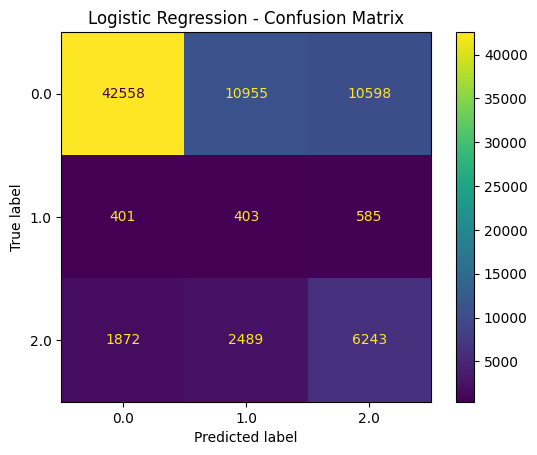

In [ ]:
# Evaluate the logistic regression model
evaluate_model("Logistic Regression", lr, X_test_scaled, y_test)


--- Random Forest ---
              precision    recall  f1-score   support

         0.0       0.89      0.77      0.83     64111
         1.0       0.02      0.10      0.03      1389
         2.0       0.32      0.40      0.35     10604

    accuracy                           0.71     76104
   macro avg       0.41      0.43      0.41     76104
weighted avg       0.80      0.71      0.75     76104

AUC-ROC (macro): 0.6501


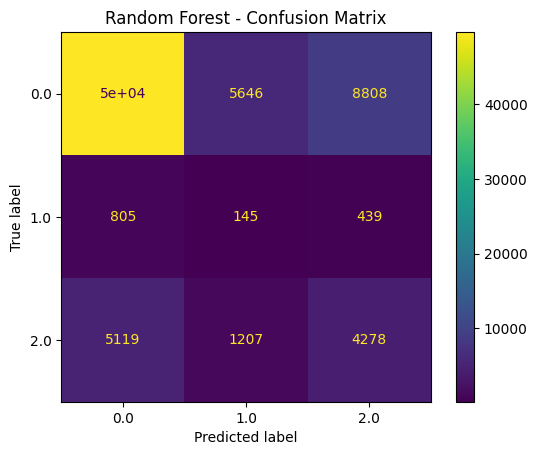

In [ ]:
# Evaluate the random forest model
evaluate_model("Random Forest", rf, X_test_scaled, y_test)


--- XGBoost ---
              precision    recall  f1-score   support

         0.0       0.95      0.64      0.76     64111
         1.0       0.03      0.27      0.05      1389
         2.0       0.34      0.60      0.43     10604

    accuracy                           0.63     76104
   macro avg       0.44      0.50      0.41     76104
weighted avg       0.85      0.63      0.70     76104

AUC-ROC (macro): 0.7482


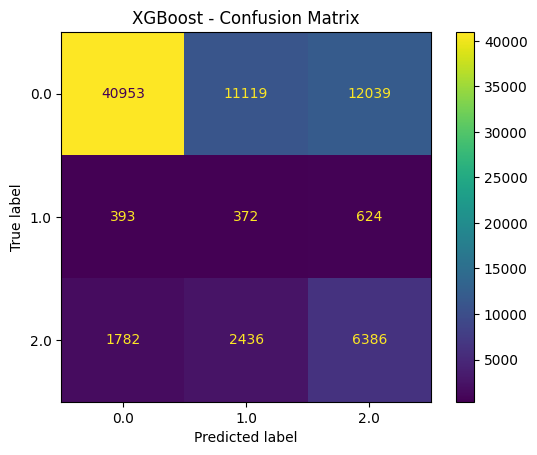

In [ ]:
# Evaluate the xgboost model
evaluate_model("XGBoost", xgb, X_test_scaled, y_test)


--- K-Nearest Neighbors ---
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91     64111
         1.0       0.02      0.00      0.01      1389
         2.0       0.43      0.21      0.28     10604

    accuracy                           0.83     76104
   macro avg       0.44      0.39      0.40     76104
weighted avg       0.79      0.83      0.80     76104

AUC-ROC (macro): 0.6571


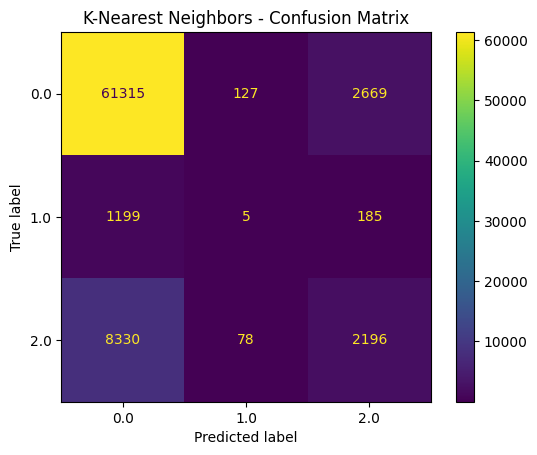

In [ ]:
# Evaluate the KNN model
evaluate_model("K-Nearest Neighbors", knn, X_test_scaled, y_test)

An initial implementation of XGBoost used `scale_pos_weight` to address class imbalance, which resulted in the model never predicting the pre-diabetic class (F1 = 0.00). Because `scale_pos_weight` is designed for binary classification, it does not meaningfully affect multiclass objectives like the one used here. After correcting this with per-sample weights, pre-diabetic recall rose from 0 to 0.27, and diabetic recall rose to 0.60.

All four models struggled to identify pre-diabetic patients, with precision staying at 2-3% across the board. Random Forest and KNN reached the highest accuracy (71% and 83%) but did so by largely ignoring the minority classes — KNN's pre-diabetic recall dropped to 0.00, and Random Forest's was only 0.10. XGBoost and Logistic Regression performed similarly, with Logistic Regression slightly ahead on macro F1 (0.43) and AUC-ROC (0.765).

Given the priority on minority-class recall over raw accuracy, **Logistic Regression was selected as the final model**.

## Feature Selection Revisited

Before tuning, we investigated whether the original 8 features were actually the best ones for distinguishing pre-diabetic patients specifically (rather than the 3-class target overall).

GenHlth                 0.059244
HighBP                  0.055109
HighChol                0.054272
BMI                     0.048327
Age                     0.046935
DiffWalk                0.039828
PhysHlth                0.032945
MentHlth                0.024744
HeartDiseaseorAttack    0.022967
NoDocbcCost             0.022184
CholCheck               0.017222
Smoker                  0.013615
Stroke                  0.011509
Sex                    -0.000725
AnyHealthcare          -0.003729
HvyAlcoholConsump      -0.006680
Fruits                 -0.009063
Veggies                -0.014805
PhysActivity           -0.024807
Education              -0.036787
Income                 -0.046269
dtype: float64


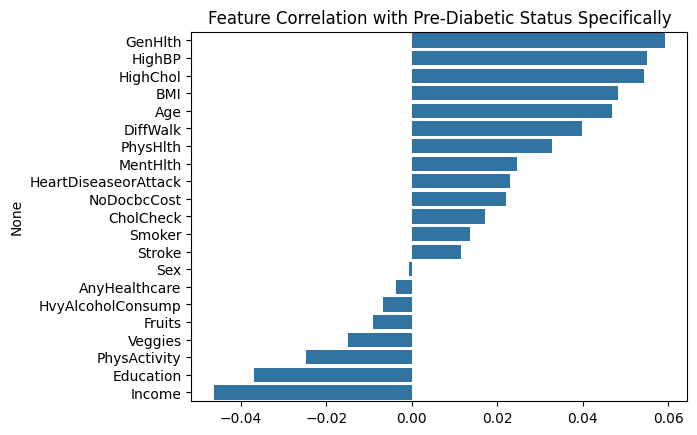

In [ ]:
# Binarize the target: 1 = pre-diabetic, 0 = everything else
diabetes_df['is_prediabetic'] = (diabetes_df['Diabetes_012'] == 1).astype(int)

# Linear correlation of ALL features against pre-diabetic status specifically
all_features = diabetes_df.drop(columns=['Diabetes_012', 'is_prediabetic']).columns
corr_prediabetic = diabetes_df[all_features].corrwith(diabetes_df['is_prediabetic']).sort_values(ascending=False)
print(corr_prediabetic)

sns.barplot(x=corr_prediabetic.values, y=corr_prediabetic.index)
plt.title('Feature Correlation with Pre-Diabetic Status Specifically')
plt.show()

BMI                     0.182202
Age                     0.141737
Income                  0.096415
PhysHlth                0.076125
GenHlth                 0.068779
MentHlth                0.065793
Education               0.065101
Smoker                  0.035247
Sex                     0.033422
Fruits                  0.033234
HighChol                0.031653
HighBP                  0.031570
PhysActivity            0.026968
Veggies                 0.025647
DiffWalk                0.019099
HeartDiseaseorAttack    0.016957
NoDocbcCost             0.014113
HvyAlcoholConsump       0.010661
Stroke                  0.010353
AnyHealthcare           0.008916
CholCheck               0.006008
dtype: float64


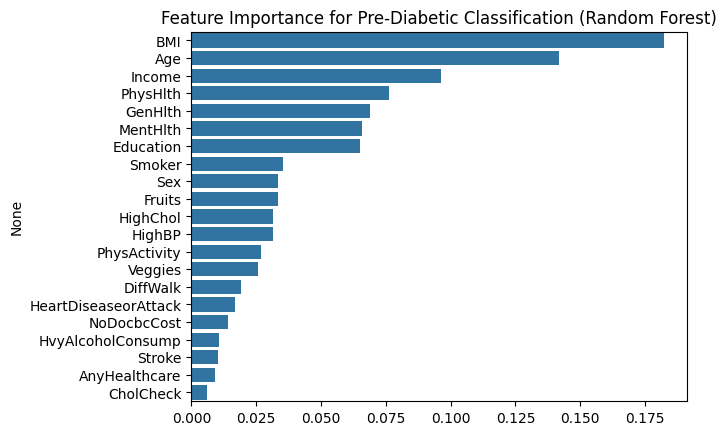

In [ ]:
# Non-linear feature importance check via Random Forest on the binary target
X_all = diabetes_df[all_features]
y_binary = diabetes_df['is_prediabetic']

rf_feature_check = RandomForestClassifier(n_estimators=100, random_state=7, class_weight='balanced')
rf_feature_check.fit(X_all, y_binary)

importances = pd.Series(rf_feature_check.feature_importances_, index=all_features).sort_values(ascending=False)
print(importances)

sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance for Pre-Diabetic Classification (Random Forest)')
plt.show()

**Findings:** Linear correlation confirmed the original 8 features (`GenHlth`, `HighBP`, `HighChol`, `BMI`, `Age`, `DiffWalk`, `PhysHlth`) were already the strongest — every correlation was under 0.06 in magnitude, reflecting very weak linear signal for pre-diabetic status overall.

The Random Forest importance check (which can catch non-linear relationships) told a different story: `Income` and `Education` showed meaningful importance (ranked 3rd and 7th) despite *negative* linear correlation — a genuine non-linear/threshold relationship correlation couldn't detect.

**Decision: `Income` and `Education` were excluded from the deployed feature set.** Although statistically informative, they were judged too sensitive to collect in an anonymous public health questionnaire, and self-reported values for these fields tend to be less reliable. This is a deliberate design tradeoff between marginal predictive gain and user trust/simplicity. Therefore, the original 8 features remain the final feature set.

## Hyperparameter Tuning (Logistic Regression)

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs'],  # supports multinomial natively — see note below
    'class_weight': [class_weight_dict, 'balanced']
}

Best params: {'C': 0.1, 'class_weight': {0: np.float64(0.3956896090700037), 1: np.float64(18.257865515114126), 2: np.float64(2.3923692506668823)}, 'penalty': 'l2', 'solver': 'lbfgs'}
Best macro F1 (CV): 0.4246009760110347

--- Logistic Regression (Tuned) ---
              precision    recall  f1-score   support

         0.0       0.95      0.66      0.78     64111
         1.0       0.03      0.29      0.05      1389
         2.0       0.36      0.59      0.45     10604

    accuracy                           0.65     76104
   macro avg       0.45      0.51      0.43     76104
weighted avg       0.85      0.65      0.72     76104

AUC-ROC (macro): 0.7650


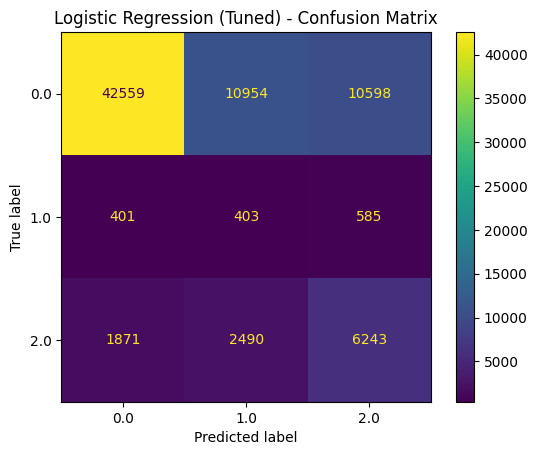

In [ ]:
# Macro F1 is used as the scoring metric since it weighs all three classes (non-diabetic, pre-diabetic, diabetic) equally

grid_search = GridSearchCV(
    LogisticRegression(max_iter=3000, random_state=7),
    param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
print("Best macro F1 (CV):", grid_search.best_score_)

lr_tuned = grid_search.best_estimator_
evaluate_model("Logistic Regression (Tuned)", lr_tuned, X_test_scaled, y_test)

Grid search across regularization strength (C: 0.01–100), penalty, and class-weighting strategy using 3-fold cross-validation returned optimal parameters nearly identical to the original defaults (C=0.1 vs. C=1.0), with no change in per-class performance. This suggests the model's limitations are driven by the underlying signal available in the selected features rather than by hyperparameter choice.

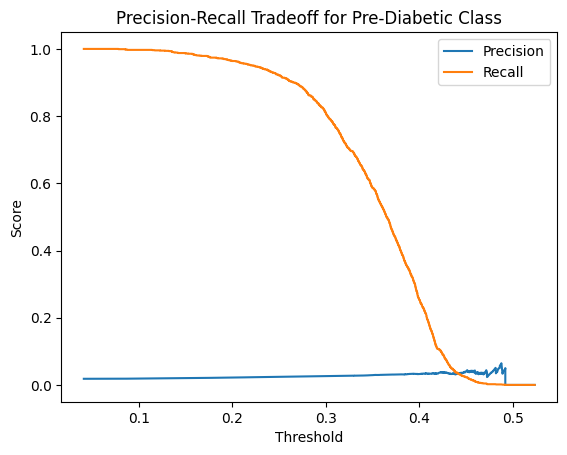

In [ ]:
# Get probability predictions for the pre-diabetic class specifically
y_probs = lr_tuned.predict_proba(X_test_scaled)[:, 1]  # class 1 = pre-diabetic

precision, recall, thresholds = precision_recall_curve((y_test == 1).astype(int), y_probs)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff for Pre-Diabetic Class')
plt.legend()
plt.show()

## Resampling Experiment: SMOTEENN

To test whether the pre-diabetic precision ceiling (~2-3% across every model and tuning attempt so far) was a class-imbalance artifact rather than a genuine separability limit, SMOTEENN (SMOTE oversampling + Edited Nearest Neighbors cleanup) was applied to the training set only to avoid leaking synthetic samples into the test set.

In [ ]:
# pip install imbalanced-learn if not already installed

from imblearn.combine import SMOTEENN

# Apply SMOTEENN only to the training set
smote_enn = SMOTEENN(random_state=7)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_scaled, y_train)

print("Original training class distribution:")
print(y_train.value_counts())
print("\nResampled training class distribution:")
print(pd.Series(y_train_resampled).value_counts())

Original training class distribution:
Diabetes_012
0.0    149592
2.0     24742
1.0      3242
Name: count, dtype: int64

Resampled training class distribution:
Diabetes_012
1.0    109383
0.0    101878
2.0     65062
Name: count, dtype: int64



--- Logistic Regression (SMOTEENN) ---
              precision    recall  f1-score   support

         0.0       0.96      0.60      0.74     64111
         1.0       0.03      0.62      0.06      1389
         2.0       0.45      0.25      0.33     10604

    accuracy                           0.55     76104
   macro avg       0.48      0.49      0.37     76104
weighted avg       0.87      0.55      0.67     76104

AUC-ROC (macro): 0.7641


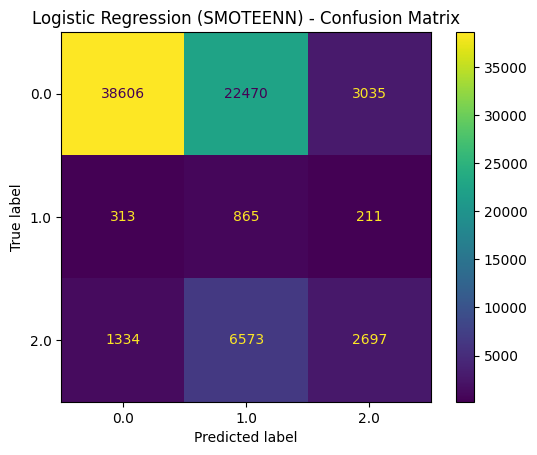

In [ ]:
# Retrain Logistic Regression on the resampled data.
# class_weight is dropped here since the resampled data is already balanced —
# combining both would over-correct.
lr_smote = LogisticRegression(C=0.1, max_iter=1000, random_state=7)
lr_smote.fit(X_train_resampled, y_train_resampled)

# Evaluate on the ORIGINAL (untouched) test set for a fair comparison
evaluate_model("Logistic Regression (SMOTEENN)", lr_smote, X_test_scaled, y_test)

SMOTEENN increased pre-diabetic recall substantially (0.29 → 0.62), but precision remained unchanged at 0.03, meaning the model still only gets it right 3% of the time when predicting pre-diabetic. Meanwhile, diabetic-class recall collapsed (0.59 → 0.25), and macro F1 dropped overall (0.43 → 0.37).

Since precision did not move despite a technique specifically designed to address class imbalance and clean up ambiguous class boundaries, this is further evidence that pre-diabetic misclassification stems from limited separability in the available features, not from class imbalance alone. SMOTEENN was not adopted since it did not improve the actual bottleneck (precision) and damaged a class that was already performing reasonably well.

## Saving the Final Model

The tuned Logistic Regression (`lr_tuned`) is the selected model. Both it **and**
the fitted `StandardScaler` must be saved together: the model was trained on
scaled features, so serving it unscaled input would produce confident but
meaningless predictions with no error raised.

The feature order and label mapping are saved in the same bundle so the API can
never drift out of sync with training.

In [ ]:
# Save the final model bundle for the API to load
import os

os.makedirs("models", exist_ok=True)

FEATURES = ['HighBP', 'HighChol', 'BMI', 'HeartDiseaseorAttack',
            'GenHlth', 'PhysHlth', 'DiffWalk', 'Age']
LABELS = {0: "non-diabetic", 1: "pre-diabetic", 2: "diabetic"}

bundle = {
    "model": lr_tuned,   # tuned Logistic Regression from GridSearchCV
    "scaler": scaler,    # MUST be saved with the model
    "features": FEATURES,
    "labels": LABELS,
}

joblib.dump(bundle, "models/diabetes_model.joblib")
print("Saved model bundle to models/diabetes_model.joblib")

# In Google Colab, download it so it survives the runtime being wiped:
# from google.colab import files
# files.download("models/diabetes_model.joblib")